In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv("cleaned_data.csv")
print(df)

        InvoiceNo StockCode                          Description  Quantity  \
0          536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1          536365     71053                  WHITE METAL LANTERN         6   
2          536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3          536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4          536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...           ...       ...                                  ...       ...   
397919     581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
397920     581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
397921     581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
397922     581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
397923     581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

                InvoiceDate  UnitPrice  CustomerID         Coun

In [2]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [3]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(snapshot_date)

2011-12-10 12:50:00


In [4]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'Revenue': 'sum'
})
rfm.columns = ['Recency','Frequency','Monetary']

print(rfm.head())

            Recency  Frequency  Monetary
CustomerID                              
12346.0         326          1  77183.60
12347.0           2          7   4310.00
12348.0          75          4   1797.24
12349.0          19          1   1757.55
12350.0         310          1    334.40


In [12]:
rfm = rfm.reset_index()

In [15]:
rfm = rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'Revenue': 'Monetary'
})

print(rfm.columns)

Index(['CustomerID', 'Recency', 'Frequency', 'Monetary', 'R_score', 'F_score',
       'M_score', 'RFM_Score', 'Segment', 'Cluster'],
      dtype='object')


In [16]:
rfm['R_score'] = pd.qcut(rfm['Recency'].rank(method='first'),4,labels=[4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'),4,labels=[4,3,2,1])
rfm['M_score'] = pd.qcut(rfm['Monetary'].rank(method='first'),4,labels=[4,3,2,1])

rfm['RFM_Score'] = (
    rfm['R_score'].astype(str) +
    rfm['F_score'].astype(str) +
    rfm['M_score'].astype(str)
)

In [17]:
def segment(row):

    if row['R_score']==4 and row['F_score']==4:
        return 'Champions'

    if row['F_score']>=3:
        return 'Loyal Customers'

    if row['R_score']>=3:
        return 'Potential Loyalists'

    if row['R_score']==1:
        return 'At Risk'

    return 'Others'

rfm['Segment'] = rfm.apply(segment, axis=1)
rfm['Segment'].value_counts()

Segment
Loyal Customers        2097
Potential Loyalists    1514
Others                  474
At Risk                 181
Champions                73
Name: count, dtype: int64

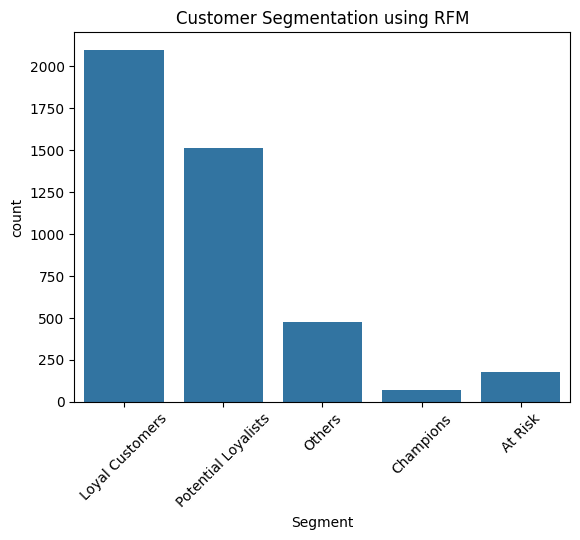

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Segment', data=rfm)
plt.title("Customer Segmentation using RFM")
plt.xticks(rotation=45)
plt.show()

In [19]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency','Frequency','Monetary']])

In [20]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4,random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

print(rfm.head())

   CustomerID  Recency  Frequency  Monetary R_score F_score M_score RFM_Score  \
0     12346.0      326          1  77183.60       1       4       1       141   
1     12347.0        2          7   4310.00       4       1       1       411   
2     12348.0       75          4   1797.24       2       2       1       221   
3     12349.0       19          1   1757.55       3       4       1       341   
4     12350.0      310          1    334.40       1       4       3       143   

               Segment  Cluster  
0      Loyal Customers        0  
1  Potential Loyalists        3  
2               Others        3  
3      Loyal Customers        3  
4      Loyal Customers        1  


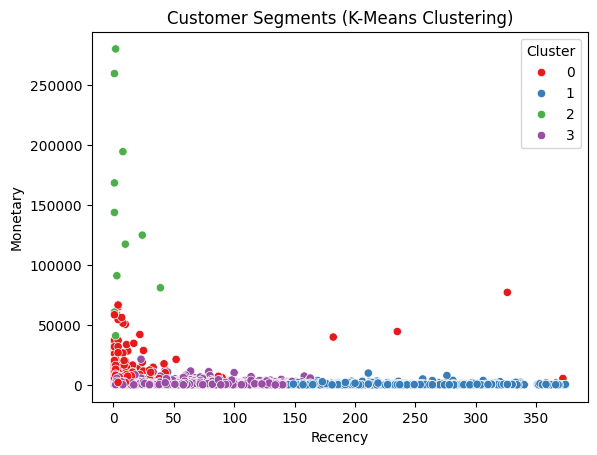

In [21]:
sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Cluster',
    palette='Set1'
)

plt.title("Customer Segments (K-Means Clustering)")
plt.show()

| Cluster | Meaning           |
| ------- | ----------------- |
| 0       | VIP Customers     |
| 1       | Loyal Customers   |
| 2       | At Risk           |
| 3       | Occasional Buyers |

Cluster 0 customers have high frequency and monetary value, representing the most valuable customer segment.


In [22]:
rfm.to_csv("rfm_final.csv", index=False)